In [1]:
from pathlib import Path
import sys
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np

sys.path.append(str(Path().resolve().parent))
from src.data_processing.data_processing import make_data_from_faculty, clean_data, make_data_from_program, make_features, process_data
from src.data_processing.data_processing import main as main_data

In [2]:
df_clean = main_data()
df_clean = clean_data(df_clean)
df_clean = process_data(df_clean)
df_clean.head()

/home/uliana/project/ml_project_2026/src/data_processing/data_processing.py:8: DtypeWarning: Columns (0: course, 1: module, 2: academic_year) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, sep=';')


,student_id_hash,campus,faculty,program,education_level,course,group,place_type,subject_name,exam_type,grade_10,absence_status,module,academic_year,student_status
0,657b2a6069af97615b4c82205863561b,Москва,факультет экономических наук,Финансовый инжиниринг,Магистратура,2,МФИИН231,Коммерческие,Дисциплина: Финансовые рынки: проблемы и решения,Первая сдача,6,attendance,1,2024,graduated
1,394b76e0ea7739201d39f8c139808de3,Москва,Высшая школа бизнеса,Управление бизнесом,Бакалавриат,4,БМБ2102,Коммерческие,Дисциплина: Управление организационной жизнест...,Первая сдача,7,attendance,1,2024,graduated
2,a6b5e298d01156513fec7056f21313c5,Москва,факультет права,Юрист в правосудии,Магистратура,2,МЮП231,Бюджетные,Дисциплина: Отбор и назначение судей,Первая сдача,8,attendance,1,2024,graduated
3,592333b03350965546a17ae33cd4d3d8,Москва,факультет права,Юрист в бизнесе,Магистратура,2,МЮБ232,Коммерческие,Дисциплина: Экономический анализ права,Первая сдача,8,attendance,1,2024,graduated
4,871132d017f31ba4bf97371ac228c638,Москва,факультет мировой экономики и мировой политики,Экономика окружающей среды и устойчивое развитие,Магистратура,2,МЭОС231,Коммерческие места для иностранных граждан,Научно-исследовательский семинар: Семинар наст...,Первая сдача,5,attendance,1,2024,graduated


In [ ]:
df_student_stats = df_clean.groupby('student_id_hash').agg({
    'program': 'first',  
    'student_id_hash': 'count'
}).rename(columns={'student_id_hash': 'count'}).reset_index()

In [4]:
df_student_stats.sort_values('count', ascending=False)

,student_id_hash,program,count
13884,385ba73871bb93cee1188276f6c1fcb1,Филология,157
32162,82efb84a5704c2714fd3d20291b74093,Юриспруденция,154
40580,a5413e3f0efda49e87768630f76f6f44,Востоковедение,152
20330,51fa6fd4677884c4da2480982bb94c6e,Управление бизнесом,149
30067,7a5c3f571484779109c2cbbeca496c26,Международный бакалавриат по бизнесу и экономике,132
...,...,...,...
51883,d30dc29a86b6cfa6209ab707bdad87e2,Анализ данных для государства и общества,1
23268,5df9d2a4e0248a66c9106db2b4a2d695,Языковые технологии в бизнесе и образовании,1
10928,2c40c7e66234626aacb4ecbb55f2a51a,Мировая экономика,1
1879,07b78bbdfa4de83cbe16af234895dc32,Психология,1


In [5]:
df_new = df_student_stats.sort_values('count', ascending=False)

In [6]:
def make_data_from_program(df : pd.DataFrame, program: str, addictional_columns: list) -> None:
    df_baseline = df.loc[(df['program'] == program) & (df['course'] == 3)]
    
    
    
    df_baseline_encoded = df_baseline.pivot_table(
        index='student_id_hash',
        columns=['course', 'module', 'subject_name'],
        values='grade_10',
        aggfunc = 'mean',
        observed=True
    )

    df_baseline_encoded.columns = [
        "_".join(map(str, col)).strip()
        for col in df_baseline_encoded.columns
    ]
    df_baseline_encoded = df_baseline_encoded.reset_index()

    df_baseline_encoded = df_baseline_encoded.merge(
        df_baseline[['student_id_hash'] + addictional_columns],
        on='student_id_hash',
        how='left'
    )
    df_baseline_encoded = df_baseline_encoded.drop_duplicates()
    return df_baseline_encoded


In [8]:
df_design = make_data_from_program(df_clean, 'Дизайн', ['student_status', 'place_type', 'program'])

In [30]:
df_design.info()

<class 'pandas.DataFrame'>
Index: 935 entries, 0 to 38976
Columns: 1300 entries, student_id_hash to student_status
dtypes: object(1298), str(2)
memory usage: 9.3+ MB


In [ ]:
threshold = 1500 
missing = df_design.isna().sum(axis = 1).sort_values(ascending=True)
print(missing[missing < 1250])

37536    1213
20201    1229
24186    1232
6953     1232
15436    1232
         ... 
15526    1249
13526    1249
33525    1249
2331     1249
5586     1249
Length: 72, dtype: int64


In [ ]:

nan_pct_cols = df_design.isna().sum() / len(df_design) * 100
df_clean_des = df_design.drop(columns=nan_pct_cols[nan_pct_cols > 50].index)

df_clean_des = df_clean_des.dropna()

print(f"Исходный размер: {df_design.shape}")
print(f"После удаления: {df_clean_des.shape}")
print(f"Сохранено ячеек: {df_clean_des.shape[0] * df_clean_des.shape[1]}")

Исходный размер: (946, 1302)
После удаления: (482, 24)
Сохранено ячеек: 11568


In [10]:
df_clean_des.to_csv('../data/raw/design_3_course.csv', index=False, encoding='utf-8')

In [36]:
df_clean_des

,student_id_hash,3_1_Дисциплина: Безопасность жизнедеятельности,3_1_Дисциплина: Специальные технологии,3_2_Дисциплина: История России,3_2_Дисциплина: История и теория дизайна. Базовый курс,3_2_Дисциплина: История классического искусства,3_2_Дисциплина: Основы российской государственности,3_2_Дисциплина: Специальные технологии,3_2_Дисциплина: Цифровая грамотность,3_3_Дисциплина: Независимый экзамен по цифровой грамотности,...,3_3_Дисциплина: Специальные технологии,3_4_Дисциплина: Внутренний экзамен по английскому языку (1 курс),3_4_Дисциплина: История России,3_4_Дисциплина: История и теория дизайна. Базовый курс,3_4_Дисциплина: История и теория дизайна. Современное искусство,3_4_Дисциплина: Независимый экзамен по программированию. Начальный уровень,3_4_Дисциплина: Правовая грамотность,3_4_Дисциплина: Специальные технологии,3_4_Дисциплина: Экономика,student_status
28,0042afc4255d18e37391b845aa044e04,10.0,7.0,9.0,8.0,9.0,10.0,7.0,6.0,5.5,...,8.0,7.0,9.0,9.0,7.0,7.5,9.0,7.0,9.0,study
118,010ef16727dd7234de23f0e7b2a766ec,6.0,5.0,7.0,8.0,9.0,9.0,6.0,7.5,9.0,...,6.0,3.0,8.0,7.0,7.0,9.0,9.0,6.0,9.0,study
174,0131b19e4c1c79fbc24520da47dc906d,9.0,8.0,9.0,9.0,9.0,9.0,8.0,6.0,6.0,...,7.0,4.0,9.0,9.0,7.0,10.0,8.0,6.0,8.0,study
216,01bc461e2eadb63e263cce89469a4875,8.0,9.0,7.0,8.0,9.0,10.0,8.0,7.0,8.0,...,7.0,4.0,6.0,8.0,8.0,6.0,6.0,8.0,9.0,study
261,01ef5e82684dc6a7e20fef7e3c2c96ec,9.0,10.0,9.0,9.0,10.0,9.0,10.0,7.5,8.0,...,9.0,6.0,8.0,10.0,9.0,10.0,9.0,9.0,8.0,study
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38598,fd3cd211ccdb941efcda0fa2b591a51f,5.0,6.0,7.0,7.0,4.666667,10.0,6.0,3.5,4.0,...,6.0,6.0,5.0,7.0,7.0,5.0,9.0,7.0,6.0,study
38690,fd936b53d240f46ea4dbffe0c8869bc3,8.0,8.0,7.0,8.0,3.5,9.0,6.0,5.5,6.0,...,7.0,6.0,7.0,8.0,7.0,4.5,8.0,7.0,7.0,study
38739,fdca69e3191498ab3e1b1399b79549d1,9.0,10.0,9.0,9.0,9.0,10.0,10.0,8.0,10.0,...,7.0,6.0,9.0,9.0,7.0,7.0,5.0,9.0,8.0,study
38835,fe762a3f9971e45bec6402b9e79228ba,9.0,9.0,7.0,9.0,6.0,9.0,9.0,6.5,7.0,...,8.0,8.0,8.0,9.0,8.0,8.0,7.0,9.0,8.0,study


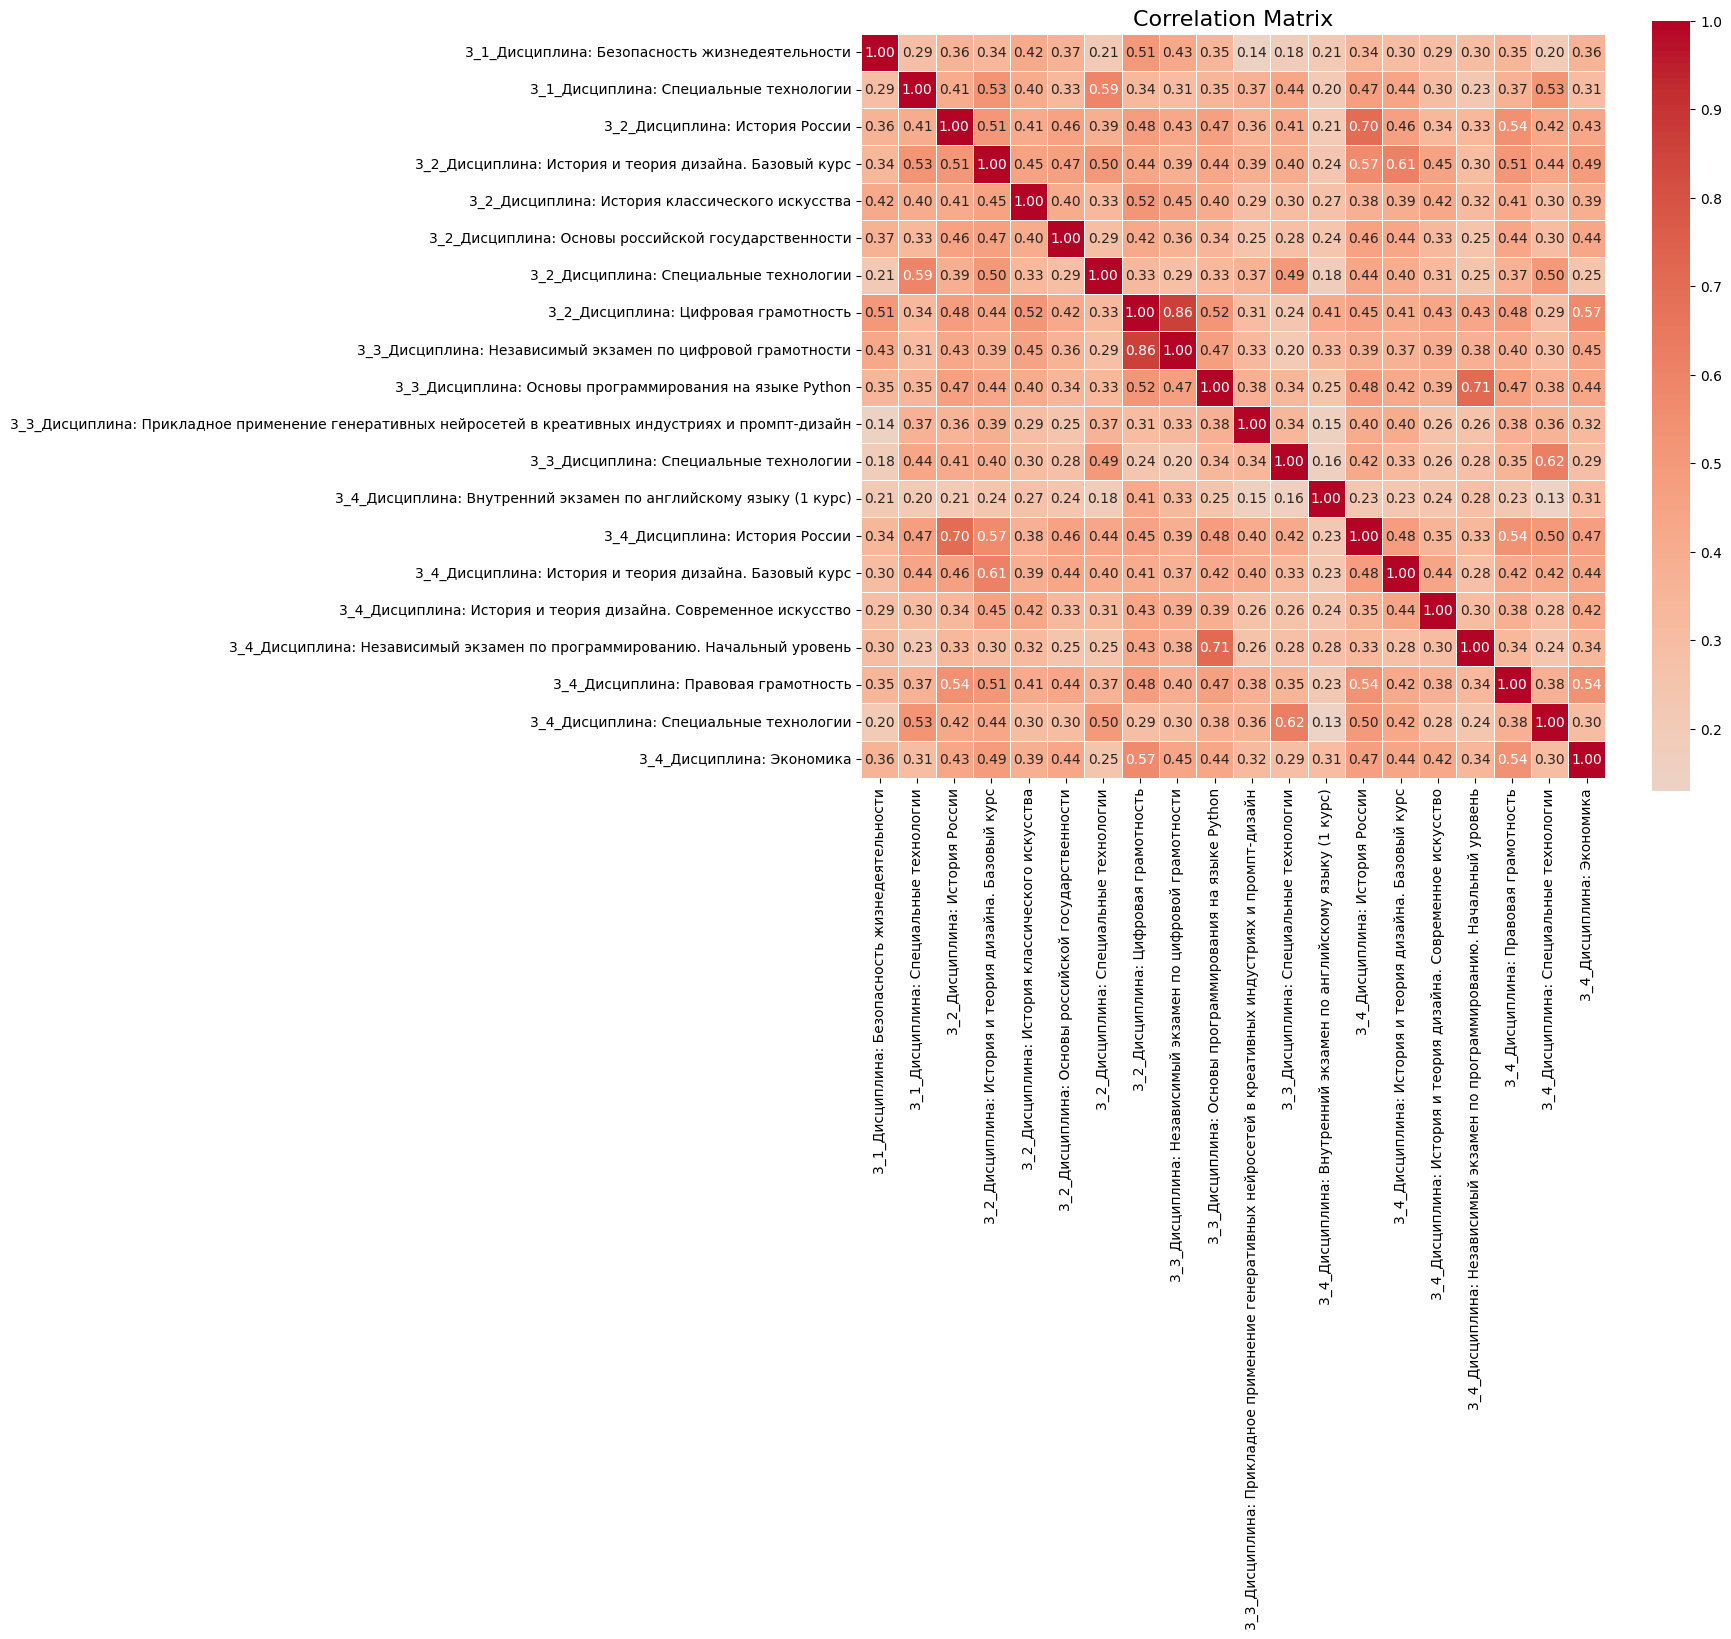

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_clean_des.drop(columns=['student_id_hash', 'student_status']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,           
            cmap='coolwarm',     
            center=0,         
            fmt='.2f',          
            linewidths=0.5,      
            square=True)         

plt.title('Correlation Matrix', fontsize=16)
# plt.tight_layout()
plt.show()